INSURANCE DATASET


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [24]:
df = pd.read_csv('/content/drive/MyDrive/IML lab work/insurance.csv')
print("Dataset loaded successfully!")
print()


Dataset loaded successfully!



In [25]:
# STEP 3: DISPLAY BASIC INFORMATION
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape:
(1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical Summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.

In [26]:
# STEP 4: SELECT INDEPENDENT AND DEPENDENT VARIABLES

# Independent Variable
X = df[["bmi"]]

# Dependent Variable / Target
y = df["charges"]

print("\nIndependent Variable:")
print("BMI")

print("\nDependent Variable:")
print("Charges")



Independent Variable:
BMI

Dependent Variable:
Charges


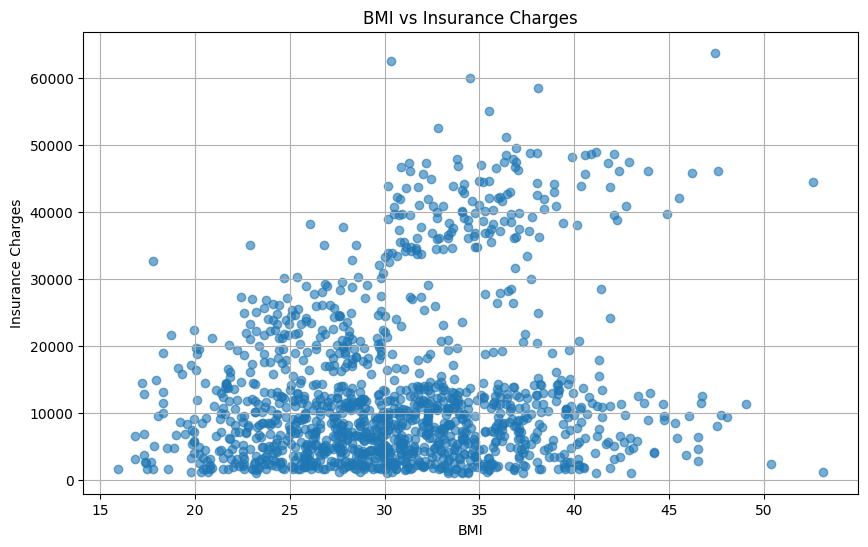

In [27]:
# STEP 5: VISUALIZE ORIGINAL DATA
plt.figure(figsize=(10, 6))

plt.scatter(
    X["bmi"],
    y,
    alpha=0.6
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")

plt.grid(True)
plt.show()


In [28]:
# ============================================================
# STEP 6: SPLIT DATA INTO TRAINING AND TESTING DATA (80/20)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.70, test_size=0.30, random_state=45
)

print("\nTraining samples (80%):", len(X_train))
print("Testing samples  (20%):", len(X_test))


Training samples (80%): 936
Testing samples  (20%): 402


In [29]:
# ============================================================
# STEP 7: SIMPLE LINEAR REGRESSION
# Degree = 1
# ============================================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("\n==============================")
print("LINEAR REGRESSION")
print("==============================")

print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

print("R² Score:",
      r2_score(y_test, y_pred_linear))

print("MAE:",
      mean_absolute_error(y_test, y_pred_linear))

print("MSE:",
      mean_squared_error(y_test, y_pred_linear))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred_linear)))



LINEAR REGRESSION
Slope: 420.7201009447393
Intercept: 669.0565815100781
R² Score: 0.022079382116680035
MAE: 8666.705162156939
MSE: 119854688.76724374
RMSE: 10947.81662100913


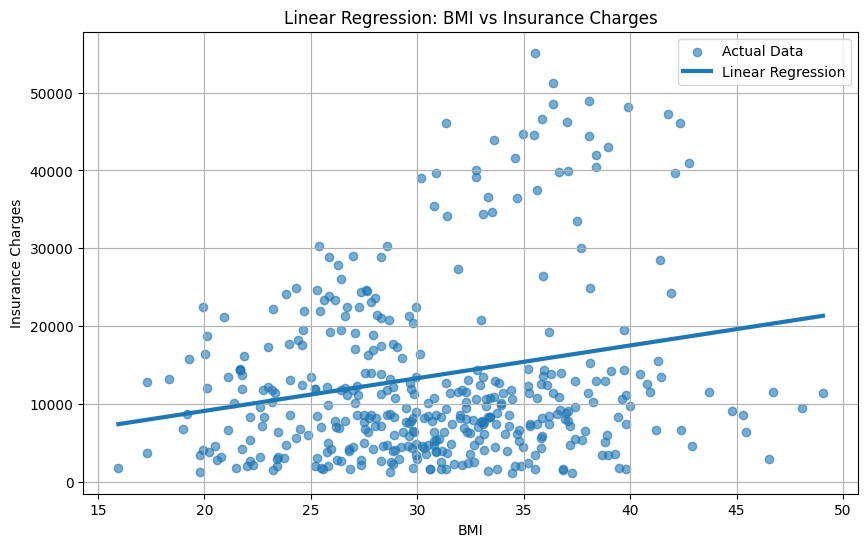

In [30]:
# STEP 8: VISUALIZE LINEAR REGRESSION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["bmi"],
    y_test,
    alpha=0.6,
    label="Actual Data"
)

# Sort values for a smooth regression line
sort_index = np.argsort(X_test["bmi"].values)

X_test_sorted = X_test.iloc[sort_index]

y_linear_sorted = linear_model.predict(X_test_sorted)

plt.plot(
    X_test_sorted["bmi"],
    y_linear_sorted,
    linewidth=3,
    label="Linear Regression"
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.title("Linear Regression: BMI vs Insurance Charges")

plt.legend()
plt.grid(True)

plt.show()


In [31]:
# STEP 9: POLYNOMIAL REGRESSION FUNCTION
# ============================================================
def polynomial_regression(degree):
  # Create polynomial features
  poly = PolynomialFeatures(degree=degree, include_bias=False)

  X_train_poly = poly.fit_transform(X_train)
  X_test_poly = poly.transform(X_test)

  # Create and train Linear Regression model
  model = LinearRegression()
  model.fit(X_train_poly, y_train)

  # Predictions
  y_train_pred = model.predict(X_train_poly)
  y_test_pred = model.predict(X_test_poly)

  # Calculate evaluation metrics
  train_r2 = r2_score(y_train, y_train_pred)
  test_r2 = r2_score(y_test, y_test_pred)
  test_mae = mean_absolute_error(y_test, y_test_pred)
  test_mse = mean_squared_error(y_test, y_test_pred)
  test_rmse = np.sqrt(test_mse)

  return (
      poly,
      model,
      y_test_pred,
      train_r2,
      test_r2,
      test_mae,
      test_mse,
      test_rmse,
  )

In [32]:
# STEP 10: TRAIN POLYNOMIAL MODELS
# Degrees 2, 3, 4 and 5
# ============================================================

degrees = [2, 3, 4, 5]

results = []

for degree in degrees:

    (
        poly,
        model,
        predictions,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ) = polynomial_regression(degree)

    results.append([
        degree,
        train_r2,
        test_r2,
        mae,
        mse,
        rmse
    ])


In [33]:
# STEP 11: DISPLAY COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame(
    results,
    columns=['Degree', 'Training R2', 'Testing R2', 'MAE', 'MSE', 'RMSE'],
)

print('\n==============================')
print('POLYNOMIAL REGRESSION RESULTS')
print('==============================')
print(results_df.round(4))


POLYNOMIAL REGRESSION RESULTS
   Degree  Training R2  Testing R2        MAE           MSE        RMSE
0       2       0.0441      0.0198  8717.7531  1.201390e+08  10960.7947
1       3       0.0448      0.0223  8729.5433  1.198317e+08  10946.7675
2       4       0.0471      0.0124  8804.8675  1.210387e+08  11001.7583
3       5       0.0473      0.0159  8790.0332  1.206093e+08  10982.2267



INDIVIDUAL DEGREE FITS ON TEST DATA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


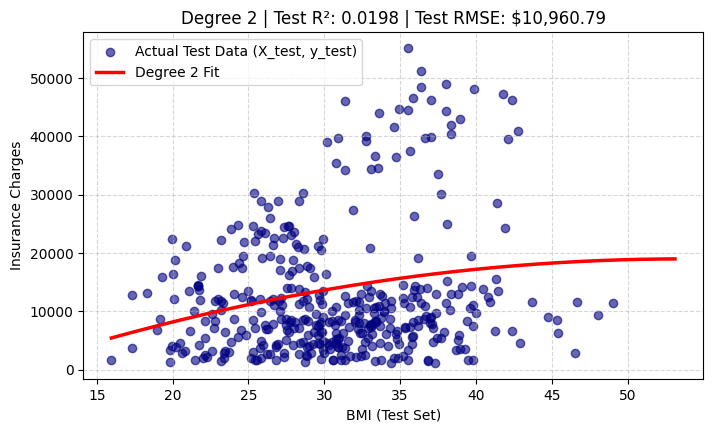

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


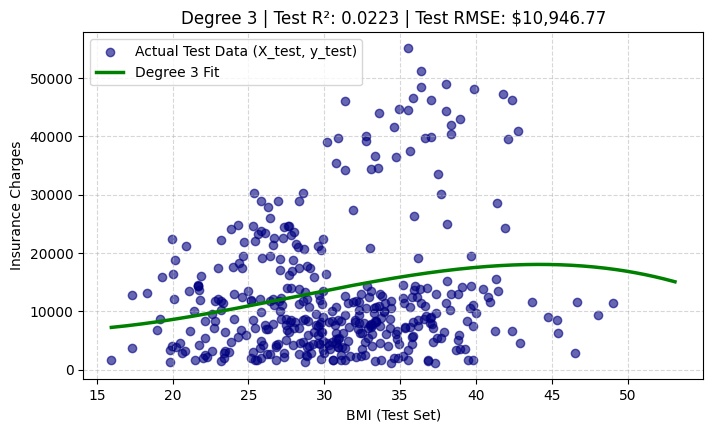

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


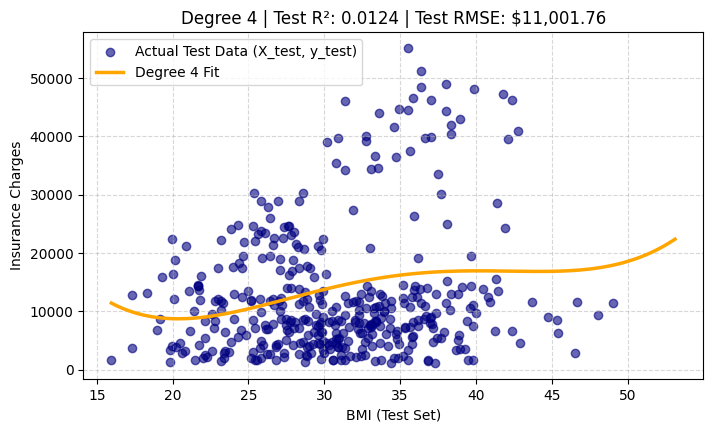

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


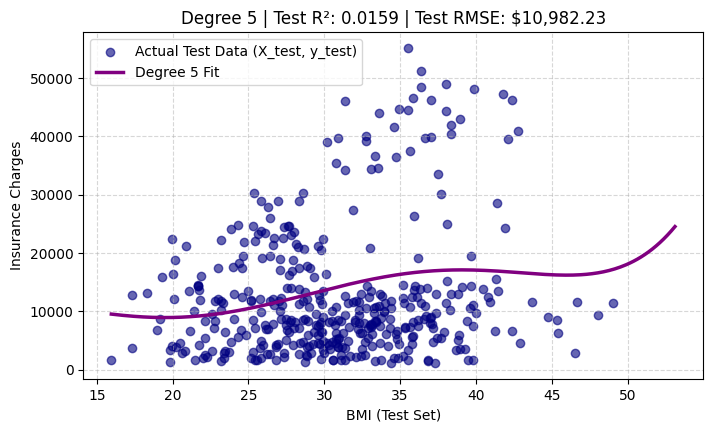

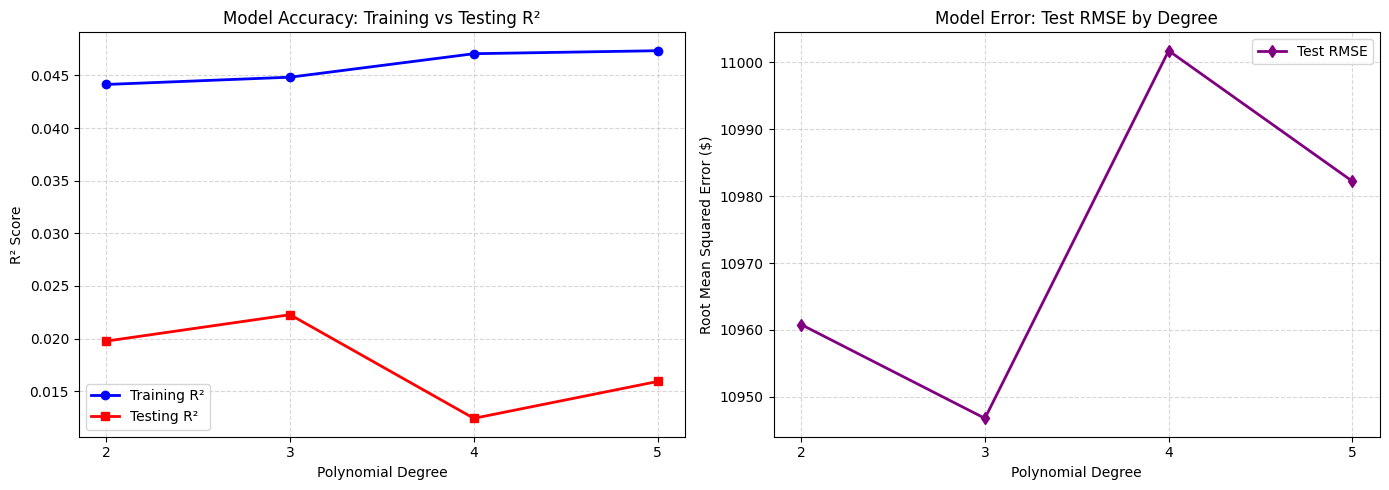

In [34]:
# ============================================================
# STEP 12: VISUALIZE POLYNOMIAL CURVES & ACCURACY ON TEST DATA
# ============================================================

# Generate smooth BMI range for continuous curve plotting
bmi_range = np.linspace(X["bmi"].min(), X["bmi"].max(), 300).reshape(-1, 1)

# Colors for degrees 2, 3, 4, 5
colors = ["red", "green", "orange", "purple"]

print("\n==============================")
print("INDIVIDUAL DEGREE FITS ON TEST DATA")
print("==============================")

# 12A: Individual Degree Plots evaluated specifically on TEST DATA
for degree, color in zip(degrees, colors):
  # Train model on polynomial features
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_train_poly = poly.fit_transform(X_train)
  X_test_poly = poly.transform(X_test)

  model = LinearRegression()
  model.fit(X_train_poly, y_train)

  # Get predictions on test set & smooth curve range
  y_test_pred = model.predict(X_test_poly)
  bmi_poly = poly.transform(bmi_range)
  curve_pred = model.predict(bmi_poly)

  # Calculate test accuracy metrics
  test_r2 = r2_score(y_test, y_test_pred)
  test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

  # Plot Test Data points vs Polynomial Curve
  plt.figure(figsize=(8, 4.5))
  plt.scatter(
      X_test["bmi"],
      y_test,
      alpha=0.6,
      color="navy",
      label="Actual Test Data (X_test, y_test)",
  )
  plt.plot(
      bmi_range,
      curve_pred,
      color=color,
      linewidth=2.5,
      label=f"Degree {degree} Fit",
  )

  # Display Accuracy (R2) and RMSE in the Title
  plt.title(
      f"Degree {degree} | Test R²: {test_r2:.4f} | Test RMSE:"
      f" ${test_rmse:,.2f}"
  )
  plt.xlabel("BMI (Test Set)")
  plt.ylabel("Insurance Charges")
  plt.legend()
  plt.grid(True, linestyle="--", alpha=0.5)
  plt.show()


# ============================================================
# STEP 12B: ACCURACY & ERROR VISUAL COMPARISON (TRAIN VS TEST R²)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training R² vs Testing R² across Degrees
axes[0].plot(
    results_df["Degree"],
    results_df["Training R2"],
    marker="o",
    color="blue",
    linewidth=2,
    label="Training R²",
)
axes[0].plot(
    results_df["Degree"],
    results_df["Testing R2"],
    marker="s",
    color="red",
    linewidth=2,
    label="Testing R²",
)
axes[0].set_title("Model Accuracy: Training vs Testing R²")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("R² Score")
axes[0].set_xticks(degrees)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Testing Error (RMSE) across Degrees
axes[1].plot(
    results_df["Degree"],
    results_df["RMSE"],
    marker="d",
    color="purple",
    linewidth=2,
    label="Test RMSE",
)
axes[1].set_title("Model Error: Test RMSE by Degree")
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("Root Mean Squared Error ($)")
axes[1].set_xticks(degrees)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [35]:
# STEP 14: DISPLAY POLYNOMIAL FEATURES
# ============================================================

poly_demo = PolynomialFeatures(
    degree=3,
    include_bias=False
)

demo_features = poly_demo.fit_transform(
    np.array([[20], [25], [30]])
)

demo_df = pd.DataFrame(
    demo_features,
    columns=["BMI", "BMI²", "BMI³"]
)

print("\n==============================")
print("POLYNOMIAL FEATURE GENERATION")
print("==============================")

print(demo_df)




POLYNOMIAL FEATURE GENERATION
    BMI   BMI²     BMI³
0  20.0  400.0   8000.0
1  25.0  625.0  15625.0
2  30.0  900.0  27000.0


In [36]:
# ============================================================
# STEP 15: FINAL ACCURACY & METRICS SUMMARY (NUMERICAL OUTPUT)
# ============================================================

print('\n' + '=' * 52)
print('         FINAL MODEL ACCURACY & PERFORMANCE        ')
print('=' * 52)

for index, row in results_df.iterrows():
  deg = int(row['Degree'])
  train_r2 = row['Training R2']
  test_r2 = row['Testing R2']
  mae = row['MAE']
  rmse = row['RMSE']

  print(f'\n--- DEGREE {deg} ---')
  print(
      f'  Training Accuracy (R² Score) : {train_r2:.4f} ({train_r2 * 100:.2f}%)'
  )
  print(
      f'  Testing Accuracy  (R² Score) : {test_r2:.4f} ({test_r2 * 100:.2f}%)'
  )
  print(f'  Mean Absolute Error (MAE)   : ${mae:,.2f}')
  print(f'  Root Mean Sq. Error (RMSE)  : ${rmse:,.2f}')

# Automatically highlight the best degree based on highest Test R² score
best_model = results_df.loc[results_df['Testing R2'].idxmax()]

print('\n' + '=' * 52)
print('                     VERDICT                      ')
print('=' * 52)
print(f' Best Performing Degree       : Degree {int(best_model["Degree"])}')
print(
    ' Highest Testing Accuracy (R²):'
    f' {best_model["Testing R2"]:.4f} ({best_model["Testing R2"] * 100:.2f}%)'
)
print(f' Lowest Test Error (RMSE)     : ${best_model["RMSE"]:,.2f}')
print('=' * 52)


         FINAL MODEL ACCURACY & PERFORMANCE        

--- DEGREE 2 ---
  Training Accuracy (R² Score) : 0.0441 (4.41%)
  Testing Accuracy  (R² Score) : 0.0198 (1.98%)
  Mean Absolute Error (MAE)   : $8,717.75
  Root Mean Sq. Error (RMSE)  : $10,960.79

--- DEGREE 3 ---
  Training Accuracy (R² Score) : 0.0448 (4.48%)
  Testing Accuracy  (R² Score) : 0.0223 (2.23%)
  Mean Absolute Error (MAE)   : $8,729.54
  Root Mean Sq. Error (RMSE)  : $10,946.77

--- DEGREE 4 ---
  Training Accuracy (R² Score) : 0.0471 (4.71%)
  Testing Accuracy  (R² Score) : 0.0124 (1.24%)
  Mean Absolute Error (MAE)   : $8,804.87
  Root Mean Sq. Error (RMSE)  : $11,001.76

--- DEGREE 5 ---
  Training Accuracy (R² Score) : 0.0473 (4.73%)
  Testing Accuracy  (R² Score) : 0.0159 (1.59%)
  Mean Absolute Error (MAE)   : $8,790.03
  Root Mean Sq. Error (RMSE)  : $10,982.23

                     VERDICT                      
 Best Performing Degree       : Degree 3
 Highest Testing Accuracy (R²): 0.0223 (2.23%)
 Lowest Tes